In [1]:
from pynwb import NWBHDF5IO
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import scipy
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001568\sub-817335\sub-817335_ses-ecephys-817335-2025-08-27-14-46-51_ecephys.nwb"

In [3]:
def gaussian_2d_sftf(coords, amplitude, log_sf0, log_tf0, sigma_sf, sigma_tf, offset):
    """
    2D Gaussian in log2(SF) x log2(TF) space (no rotation term).
    Axis-aligned, matching the separable assumption for tuning curves.

    Parameters
    ----------
    coords : tuple of (log_sf_grid, log_tf_grid), each flattened
    amplitude : peak amplitude above baseline
    log_sf0 : preferred SF in log2 units
    log_tf0 : preferred TF in log2 units
    sigma_sf : tuning width in log2 SF
    sigma_tf : tuning width in log2 TF
    offset : baseline firing rate
    """
    log_sf, log_tf = coords
    g = offset + amplitude * np.exp(
        -(
            (log_sf - log_sf0) ** 2 / (2 * sigma_sf ** 2) +
            (log_tf - log_tf0) ** 2 / (2 * sigma_tf ** 2)
        )
    )
    return g.ravel()

def fit_sftf_gaussian(sf_vals, tf_vals, response_matrix):
    """
    Fit a 2D Gaussian to an SF x TF response matrix in log2 frequency space.

    Parameters
    ----------
    sf_vals : array-like of shape (n_sf,)
        Spatial frequency values tested (linear units, e.g. cycles/deg)
    tf_vals : array-like of shape (n_tf,)
        Temporal frequency values tested (linear units, e.g. Hz)
    response_matrix : array-like of shape (n_sf, n_tf)
        Mean spike rates; rows index SF, columns index TF

    Returns
    -------
    pref_sf : float or None
        Preferred spatial frequency in linear units
    pref_tf : float or None
        Preferred temporal frequency in linear units
    r_squared : float or None
        Goodness of fit (R²)
    popt : array or None
        Raw fitted parameters [amplitude, log_sf0, log_tf0, sigma_sf, sigma_tf, offset]
    """
    sf_vals = np.array(sf_vals, dtype=float)
    tf_vals = np.array(tf_vals, dtype=float)
    response_matrix = np.array(response_matrix, dtype=float)

    # Build log2 grids
    log_sf = np.log2(sf_vals)
    log_tf = np.log2(tf_vals)
    log_sf_grid, log_tf_grid = np.meshgrid(log_sf, log_tf, indexing='ij')  # shape (n_sf, n_tf)
    z = response_matrix.ravel()

    # Initial guesses from argmax
    flat_idx = np.argmax(response_matrix)
    sf_idx, tf_idx = np.unravel_index(flat_idx, response_matrix.shape)

    amplitude_guess = response_matrix.max() - response_matrix.min()
    log_sf0_guess = log_sf[sf_idx]
    log_tf0_guess = log_tf[tf_idx]
    sigma_sf_guess = (log_sf[-1] - log_sf[0]) / 4.0 if len(log_sf) > 1 else 1.0
    sigma_tf_guess = (log_tf[-1] - log_tf[0]) / 4.0 if len(log_tf) > 1 else 1.0
    offset_guess = response_matrix.min()

    initial_guess = (amplitude_guess, log_sf0_guess, log_tf0_guess, sigma_sf_guess, sigma_tf_guess, offset_guess)

    bounds = (
        [0,          log_sf[0],  log_tf[0],  0.1, 0.1, -np.inf],
        [np.inf,     log_sf[-1], log_tf[-1], 10,  10,   np.inf]
    )

    coords = (log_sf_grid.ravel(), log_tf_grid.ravel())

    def _r_squared(z_data, z_fit):
        ss_res = np.sum((z_data - z_fit) ** 2)
        ss_tot = np.sum((z_data - np.mean(z_data)) ** 2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

    try:
        popt, _ = curve_fit(
            gaussian_2d_sftf,
            coords,
            z,
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )
        z_fit = gaussian_2d_sftf(coords, *popt)
        r_squared = _r_squared(z, z_fit)

        if r_squared < -0.5:
            print(f"Warning: SF/TF Gaussian fit R² = {r_squared:.3f}, rejecting")
            return None, None, None, None

        pref_sf = 2 ** popt[1]  # convert log2 back to linear
        pref_tf = 2 ** popt[2]

        return pref_sf, pref_tf, r_squared, popt

    except RuntimeError:
        # Bounded fit failed — retry without bounds
        try:
            popt, _ = curve_fit(
                gaussian_2d_sftf,
                coords,
                z,
                p0=p0,
                maxfev=10000
            )
            z_fit = gaussian_2d_sftf(coords, *popt)
            r_squared = _r_squared(z, z_fit)
            pref_sf = 2 ** popt[1]
            pref_tf = 2 ** popt[2]
            return pref_sf, pref_tf, r_squared, popt

        except Exception as e:
            print(f"SF/TF Gaussian fit failed (unbounded): {e}")
            return None, None, None, None

    except Exception as e:
        print(f"SF/TF Gaussian fit failed: {e}")
        return None, None, None, None

In [4]:
def presentationwise_spike_times(nwb, stim_table, stimulus_presentation_ids=None, unit_ids=None):
    """
    Produce a table associating spike times with units and stimulus presentations.
    
    Based on AllenSDK implementation.
    
    Parameters
    ----------
    nwb : NWBFile
        NWB file object
    stim_table : DataFrame
        Stimulus presentation table
    stimulus_presentation_ids : array-like, optional
        Filter to these stimulus presentations
    unit_ids : array-like, optional
        Filter to these units
    
    Returns
    -------
    pandas.DataFrame :
        Index: spike_time (float)
        Columns: stimulus_presentation_id, unit_id, time_since_stimulus_presentation_onset
    """
    if stimulus_presentation_ids is not None:
        stim_table = stim_table.loc[stimulus_presentation_ids]
    
    # Get units
    units_table = nwb.units.to_dataframe()
    if unit_ids is None:
        unit_ids = units_table.index.values
    
    # Create presentation_times array (alternating start/stop times)
    presentation_times = np.zeros([stim_table.shape[0] * 2])
    presentation_times[::2] = np.array(stim_table['start_time'])
    presentation_times[1::2] = np.array(stim_table['stop_time'])
    
    all_presentation_ids = np.array(stim_table.index.values)
    
    presentation_ids = []
    unit_ids_list = []
    spike_times_list = []
    
    for unit_id in unit_ids:
        # Retrieve spike times for this unit
        unit_row_index = units_table.index.get_loc(unit_id)
        data = nwb.units['spike_times'][unit_row_index]
        
        # Find which presentation each spike belongs to using searchsorted
        indices = np.searchsorted(presentation_times, data) - 1
        
        index_valid = indices % 2 == 0
        
        # Get presentation IDs
        presentations = all_presentation_ids[np.floor(indices / 2).astype(int)]
        
        # Sort by presentation
        sorder = np.argsort(presentations)
        presentations = presentations[sorder]
        index_valid = index_valid[sorder]
        data = data[sorder]
        
        # Find boundaries between different presentations
        changes = np.where(np.ediff1d(presentations, to_begin=1, to_end=1))[0]
        
        for ii, jj in zip(changes[:-1], changes[1:]):
            values = data[ii:jj][index_valid[ii:jj]]
            if values.size == 0:
                continue
            unit_ids_list.append(np.zeros([values.size]) + unit_id)
            presentation_ids.append(np.zeros([values.size]) + presentations[ii])
            spike_times_list.append(values)
    
    if not spike_times_list:
        # If there are no spikes, return empty DataFrame
        return pd.DataFrame(columns=[
            'stimulus_presentation_id',
            'unit_id',
            'time_since_stimulus_presentation_onset'])
    
    pres_ids = np.concatenate(presentation_ids).astype(int)
    spike_df = pd.DataFrame({
        'stimulus_presentation_id': pres_ids,
        'unit_id': np.concatenate(unit_ids_list).astype(int)
    }, index=pd.Index(np.concatenate(spike_times_list), name='spike_time'))
    
    # Add time since stimulus presentation onset
    onset_times = stim_table.loc[all_presentation_ids, "start_time"]
    spikes_with_onset = spike_df.join(onset_times, on=["stimulus_presentation_id"])
    spikes_with_onset["time_since_stimulus_presentation_onset"] = (
        spikes_with_onset.index - spikes_with_onset["start_time"]
    )
    spikes_with_onset.sort_values(by='spike_time', axis=0, inplace=True)
    spikes_with_onset.drop(columns=["start_time"], inplace=True)
    
    return spikes_with_onset

# from lines 1491-1500 AllenSDK/allensdk/brain_observatory/ecephys/ecephys_session.py
# https://github.com/AllenInstitute/AllenSDK/blob/a9b5c685396126d9748f1ccecf7c00f440569f69/allensdk/brain_observatory/ecephys/ecephys_session.py
def _extract_summary_count_statistics(index, group):
    """
    Extract summary statistics for spike counts.
    
    Based on AllenSDK implementation.
    """
    return {
        "stimulus_condition_id": index[0],
        "unit_id": index[1],
        "spike_count": group["spike_count"].sum(),
        "stimulus_presentation_count": group.shape[0],
        "spike_mean": np.mean(group["spike_count"].values),
        "spike_std": np.std(group["spike_count"].values, ddof=1),
        "spike_sem": scipy.stats.sem(group["spike_count"].values)
    }

# from lines 891-980 AllenSDK/allensdk/brain_observatory/ecephys/ecephys_session.py
# https://github.com/AllenInstitute/AllenSDK/blob/a9b5c685396126d9748f1ccecf7c00f440569f69/allensdk/brain_observatory/ecephys/ecephys_session.py
def conditionwise_spike_statistics(nwb, stimulus_block='drifting_gratings_field_block_presentations',
                                   stimulus_presentation_ids=None, unit_ids=None):
    """
    Calculate spike statistics grouped by stimulus condition.
    
    Based on AllenSDK implementation.
    
    Parameters
    ----------
    nwb : NWBFile
        NWB file object
    stimulus_block : str
        Which stimulus block to analyze
    stimulus_presentation_ids : array-like, optional
        Filter to these stimulus presentations
    unit_ids : array-like, optional
        Filter to these units
    
    Returns
    -------
    tuple : (result_df, stimulus_conditions)
        result_df: DataFrame with spike statistics indexed by [unit_id, stimulus_condition_id]
        stimulus_conditions: DataFrame with stimulus parameters indexed by stimulus_condition_id
    """
    # Get the appropriate stimulus table
    if stimulus_block not in nwb.intervals:
        available = list(nwb.intervals.keys())
        raise ValueError(f"Stimulus block '{stimulus_block}' not found. Available: {available}")
    
    stim_table = nwb.intervals[stimulus_block].to_dataframe()
    
    if stimulus_presentation_ids is None:
        stimulus_presentation_ids = stim_table.index.values
    
    condition_params = ['orientation', 'temporal_frequency', 'spatial_frequency', 'contrast']
    
    # Get rid of all rows that have NA in condition parameters
    stim_table_clean = stim_table[condition_params + ['start_time', 'stop_time']].dropna(subset=condition_params).copy()
    
    # Convert strings to floats
    for param in condition_params:
        if param in stim_table_clean.columns:
            stim_table_clean[param] = pd.to_numeric(stim_table_clean[param], errors='coerce')
    
    stimulus_presentation_ids = stim_table_clean.index.values
    
    # Create stimulus_condition_id
    stim_table_clean['stimulus_condition_id'] = stim_table_clean.groupby(condition_params).ngroup()
    
    presentations = stim_table_clean.loc[stimulus_presentation_ids].copy()
    
    # Get presentationwise spike times
    spikes = presentationwise_spike_times(nwb, stim_table_clean, stimulus_presentation_ids, unit_ids)
    
    if spikes.empty:
        # No spikes case
        units_table = nwb.units.to_dataframe()
        if unit_ids is None:
            unit_ids = units_table.index.values
        
        spike_counts = pd.DataFrame(
            {'spike_count': 0},
            index=pd.MultiIndex.from_product([
                stimulus_presentation_ids,
                unit_ids],
                names=['stimulus_presentation_id', 'unit_id']))
    else:
        # Count spikes per presentation and unit
        spike_counts = spikes[['stimulus_presentation_id', 'unit_id']].copy()
        spike_counts["spike_count"] = np.zeros(spike_counts.shape[0])
        spike_counts = spike_counts.groupby(["stimulus_presentation_id", "unit_id"]).count()
        
        unit_ids = unit_ids if unit_ids is not None else spikes['unit_id'].unique()
        
        spike_counts = spike_counts.reindex(
            pd.MultiIndex.from_product(
                [stimulus_presentation_ids, unit_ids],
                names=['stimulus_presentation_id', 'unit_id']),
            fill_value=0)
    
    # Merge with presentations to get stimulus_condition_id
    sp = pd.merge(
        spike_counts,
        presentations[['stimulus_condition_id']],
        left_on="stimulus_presentation_id",
        right_index=True,
        how="left"
    )
    sp.reset_index(inplace=True)
    
    # Extract summary statistics
    summary = []
    for ind, gr in sp.groupby(["stimulus_condition_id", "unit_id"]):
        summary.append(_extract_summary_count_statistics(ind, gr))
    
    result_df = pd.DataFrame(summary).set_index(keys=["unit_id", "stimulus_condition_id"])
    
    # Create stimulus_conditions table
    stimulus_conditions = stim_table_clean[condition_params + ['stimulus_condition_id']].drop_duplicates(
        subset='stimulus_condition_id'
    ).set_index('stimulus_condition_id').sort_index()
    
    return result_df, stimulus_conditions

def get_unit_probe(unit_idx, units):
    """Get the probe/device name for a unit."""
    return str(units['device_name'][unit_idx])


def select_condition(unit_idx, units, probe, all_units=False):
    """
    Determine if a unit meets selection criteria.
    
    Parameters:
    -----------
    unit_idx : int
        Index of the unit
    units : DataFrame
        Units table from NWB file
    probe : str
        Target probe name
    all_units : bool
        If True, include all units regardless of SNR
    
    Returns:
    --------
    bool : Whether the unit meets selection criteria
    """
    if all_units:
        return get_unit_probe(unit_idx, units) == probe
    
    return (units["snr"][unit_idx] > 1 and 
            get_unit_probe(unit_idx, units) == probe)


def get_rf(spike_times, xs, ys, rf_stim_table):
    """
    Calculate receptive field from spike times and stimulus presentations.
    
    Parameters:
    -----------
    spike_times : array
        Spike times for the unit
    xs : array
        X positions of RF stimuli
    ys : array
        Y positions of RF stimuli
    rf_stim_table : DataFrame
        Receptive field stimulus presentation table
    
    Returns:
    --------
    ndarray : 2D receptive field response matrix
    """
    unit_rf = np.zeros([ys.size, xs.size])
    
    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):
            # Get stimulus times for this coordinate
            stim_times = rf_stim_table[
                (rf_stim_table.x_position == str(x)) & 
                (rf_stim_table.y_position == str(y))
            ].start_time
            
            response_spike_count = 0
            for stim_time in stim_times:
                # Count spikes within 0.2 seconds after stimulus
                start_idx, end_idx = np.searchsorted(
                    spike_times, 
                    [stim_time, stim_time + 0.2]
                )
                response_spike_count += end_idx - start_idx
            
            unit_rf[yi, xi] = response_spike_count
    
    return unit_rf

In [5]:
def process_units(nwb_data, probe, all_units=False, verbose=False):
    """
    Process units from NWB data to get receptive fields.
    
    Parameters:
    -----------
    nwb_data : dict
        Dictionary from load_nwb_data
    probe : str
        Target probe name
    all_units : bool
        Whether to include all units
    verbose : bool
        Print detailed information
    
    Returns:
    --------
    dict : Dictionary containing unit data
    """
    units = nwb_data['units']
    rf_stim_table = nwb_data['rf_stim_table']
    nwb = nwb_data['nwb']
    
    # Get unique RF positions
    xs = list(set(rf_stim_table.x_position))
    ys = list(set(rf_stim_table.y_position))

    xs = [float(x) for x in xs]
    ys = [float(y) for y in ys]

    xs = np.sort(xs)
    ys = np.sort(ys)
    if verbose:
        print(f"    RF grid: xs={xs}, ys={ys}")
    
    # Find units matching criteria
    unit_indices = []
    unit_rfs = []
    
    for unit_idx in range(len(units)):
        if select_condition(unit_idx, units, probe):
            unit_indices.append(unit_idx)
            
            # Get spike times and calculate RF
            spike_times = nwb.units['spike_times'][unit_idx]
            unit_rf = get_rf(spike_times, xs, ys, rf_stim_table)
            unit_rfs.append(unit_rf)
    
    if verbose:
        print(f"    Found {len(unit_indices)} units on {probe}")
        print(f"    RF grid size: {len(xs)} x {len(ys)}")
    
    return {
        'unit_indices': unit_indices,
        'unit_rfs': unit_rfs,
        'xs': xs,
        'ys': ys
    }

In [6]:
io = NWBHDF5IO(str(nwb_path), 'r', load_namespaces=True)
nwb = io.read()

units = nwb.units
rf_stim_table = nwb.intervals['receptive_field_block_presentations'].to_dataframe()
dg_stim_table = nwb.intervals['drifting_gratings_field_block_presentations'].to_dataframe()

nwb_data = {
    'nwb': nwb,
    'units': units, 
    'rf_stim_table': rf_stim_table,
    'dg_stim_table': dg_stim_table
}

probes_to_analyze = sorted(set(units['device_name'][:]))

print(probes_to_analyze)
print(f"Total units: {len(units)}")

['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
Total units: 2403


In [7]:
units_data = process_units(
                        nwb_data=nwb_data,
                        probe='ProbeA',
                        all_units=False,
                        verbose=False
                    )

In [8]:
unit_indices = units_data['unit_indices']

conditionwise_stats, stimulus_conditions = conditionwise_spike_statistics(
            nwb,
            stimulus_block='drifting_gratings_field_block_presentations',
            stimulus_presentation_ids=dg_stim_table.index.values,
            unit_ids=unit_indices  # Pass all unit IDs at once
        )


In [9]:
# Get unique stimulus values
ori_vals = np.sort(stimulus_conditions['orientation'].unique())
tf_vals = np.sort(stimulus_conditions['temporal_frequency'].unique())
sf_vals = np.sort(stimulus_conditions['spatial_frequency'].unique())

print("Unique stimulus values:")
print(f"Orientations: {ori_vals}")
print(f"Temporal Frequencies: {tf_vals}")
print(f"Spatial Frequencies: {sf_vals}")

Unique stimulus values:
Orientations: [  0.  45.  90. 135.]
Temporal Frequencies: [ 1.  2.  4.  8. 15.]
Spatial Frequencies: [0.02 0.04 0.08 0.16 0.32]


Randomly selected unit index: 548


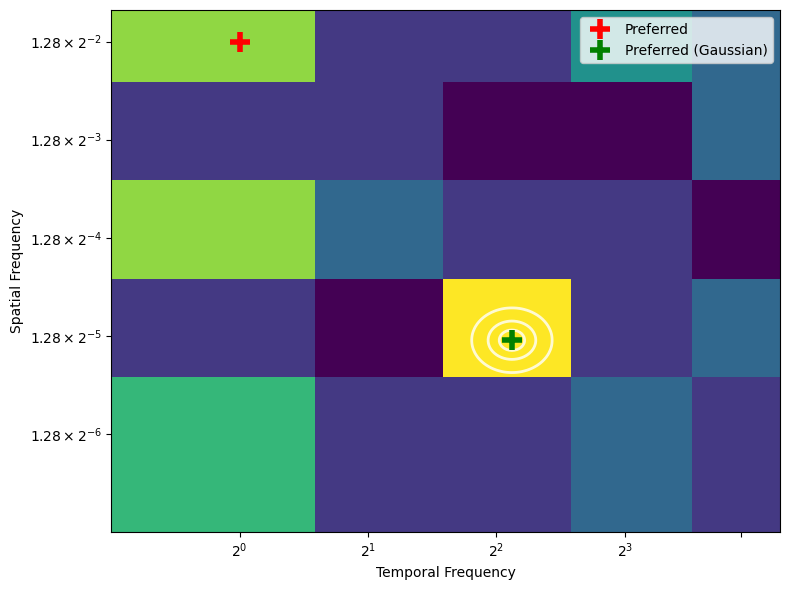

Preferred TF: 1.0
Preferred TF from Gaussian fit: 4.351980857656493
Preferred SF: 0.32
Preferred SF from Gaussian fit: 0.03879705452524499


In [139]:
random_idx = np.random.choice(unit_indices)
print(f"Randomly selected unit index: {random_idx}")
unit_stats = conditionwise_stats.loc[random_idx] 

# Step 1: Calculate preferred orientation (across all TFs and SFs)
ori_responses = []
for ori in ori_vals:
    ori_conditions = stimulus_conditions[
        stimulus_conditions['orientation'] == ori
    ].index.values
    
    try:
        mean_response = unit_stats.loc[ori_conditions]['spike_mean'].mean()
        mean_response = float(mean_response)
    except (KeyError, ValueError, TypeError):
        mean_response = 0.0
    ori_responses.append(mean_response)

pref_ori = ori_vals[np.argmax(ori_responses)]

tf_responses = []
for tf in tf_vals:
    ori_tf_conditions = stimulus_conditions[
        (stimulus_conditions['orientation'] == pref_ori) & 
        (stimulus_conditions['temporal_frequency'] == tf)
    ].index.values
    
    try:
        mean_response = unit_stats.loc[ori_tf_conditions]['spike_mean'].mean()
        mean_response = float(mean_response)
    except (KeyError, ValueError, TypeError):
        mean_response = 0.0
    tf_responses.append(mean_response)

pref_tf_temp = tf_vals[np.argmax(tf_responses)]

sf_responses = []
for sf in sf_vals:
    ori_sf_conditions = stimulus_conditions[
        (stimulus_conditions['orientation'] == pref_ori) & 
        (stimulus_conditions['spatial_frequency'] == sf)
    ].index.values
    
    try:
        mean_response = unit_stats.loc[ori_sf_conditions]['spike_mean'].mean()
        mean_response = float(mean_response)
    except (KeyError, ValueError, TypeError):
        mean_response = 0.0
    sf_responses.append(mean_response)

pref_sf_temp = sf_vals[np.argmax(sf_responses)]

sftf_matrix = np.full((len(sf_vals), len(tf_vals)), np.nan)
for i, sf in enumerate(sf_vals):
    for j, tf in enumerate(tf_vals):
        conditions = stimulus_conditions[
            (stimulus_conditions['orientation'] == pref_ori) &
            (stimulus_conditions['spatial_frequency'] == sf) &
            (stimulus_conditions['temporal_frequency'] == tf)
        ].index.values
        
        try:
            mean_response = unit_stats.loc[conditions]['spike_mean'].mean()
            mean_response = float(mean_response)
        except (KeyError, ValueError, TypeError):
            mean_response = 0.0
        sftf_matrix[i, j] = mean_response

sftf_matrix = np.nan_to_num(sftf_matrix, nan=0.0)
pref_sf_gaussian, pref_tf_gaussian, r_squared_gaussian, popt = fit_sftf_gaussian(sf_vals, tf_vals, sftf_matrix)


# plt.figure(figsize=(8, 6))

# plt.imshow(sftf_matrix, aspect='auto', origin='lower',
#            extent=[tf_vals[0], tf_vals[-1], sf_vals[0], sf_vals[-1]])


fig, ax = plt.subplots(figsize=(8, 6))

# pcolormesh uses actual coordinate values, not linear interpolation
ax.pcolormesh(tf_vals, sf_vals, sftf_matrix)

# Set log scale so spacing matches how the Gaussian was fit
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)

if popt is not None:
    # Build fine grid in log2 space (matching how the Gaussian was fit)
    log_sf_fine = np.linspace(np.log2(sf_vals[0]), np.log2(sf_vals[-1]), 200)
    log_tf_fine = np.linspace(np.log2(tf_vals[0]), np.log2(tf_vals[-1]), 200)
    log_sf_grid, log_tf_grid = np.meshgrid(log_sf_fine, log_tf_fine, indexing='ij')

    # Evaluate fitted Gaussian on the fine grid
    coords_fine = (log_sf_grid.ravel(), log_tf_grid.ravel())
    gaussian_fine = gaussian_2d_sftf(coords_fine, *popt).reshape(log_sf_grid.shape)

    # Convert back to linear so coordinates match the log-scaled axis values
    sf_fine_linear = 2 ** log_sf_fine
    tf_fine_linear = 2 ** log_tf_fine

    ax.contour(tf_fine_linear, sf_fine_linear, gaussian_fine,
               levels=2, colors='white', linewidths=2, alpha=0.8)
    ax.plot(pref_tf_temp, pref_sf_temp, 'r+', markersize=14, markeredgewidth=4, label='Preferred')
    ax.plot(pref_tf_gaussian, pref_sf_gaussian, 'g+', markersize=14, markeredgewidth=4, label='Preferred (Gaussian)')
    ax.legend()


plt.ylabel('Spatial Frequency')
plt.yticks(sf_vals)
plt.xlabel('Temporal Frequency')
plt.xticks(tf_vals)
plt.tight_layout()
plt.show()

print(f"Preferred TF: {pref_tf_temp}")
print(f"Preferred TF from Gaussian fit: {pref_tf_gaussian}")
print(f"Preferred SF: {pref_sf_temp}")
print(f"Preferred SF from Gaussian fit: {pref_sf_gaussian}")

Preferred variables:
Preferred SF: 0.320, TF: 1.000, Ori: 135.0°
Gaussian:
Preferred SF: 0.040, TF: 4.002, Ori: 114.7°
Sigma ori: 13.1° — ok


C:\Users\MaryBeth\AppData\Local\Temp\ipykernel_51592\2601377789.py:106: UserWarning: No contour levels were found within the data range.
  ax.contour(tf_fine_linear, sf_fine_linear, gaussian_slice,


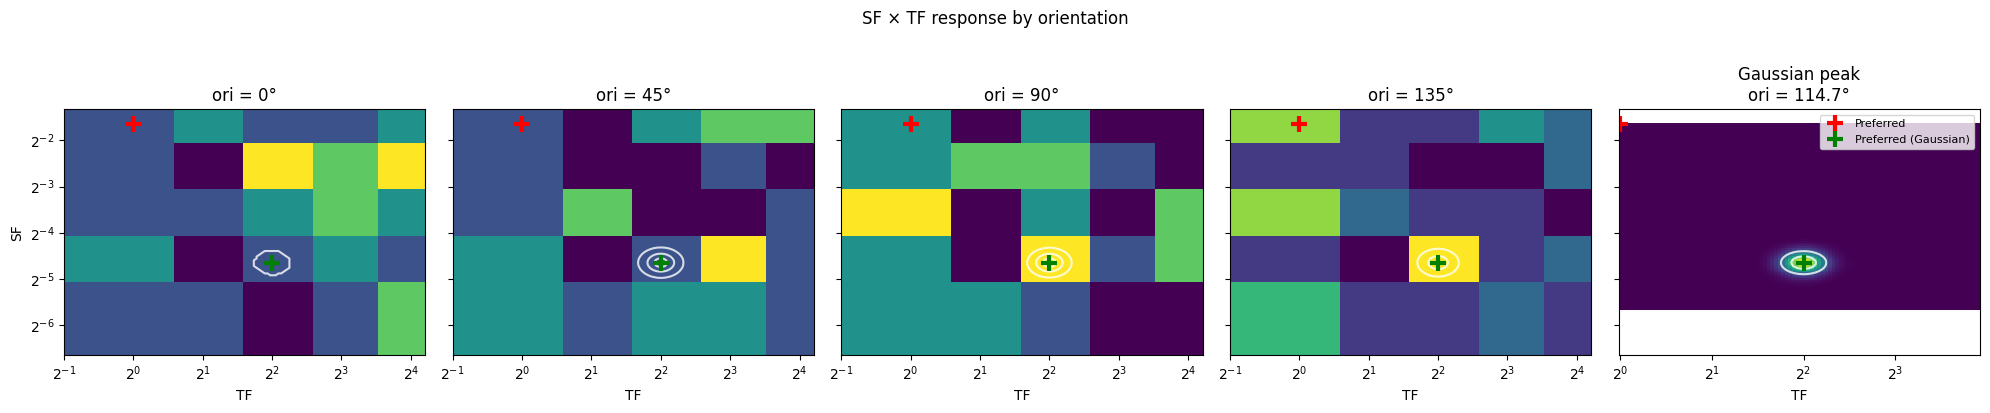

In [140]:
from scipy.optimize import curve_fit
import numpy as np

def gaussian_3d_sftf_ori(coords, amplitude, mu_sf, mu_tf, mu_ori,
                          sigma_sf, sigma_tf, sigma_ori, offset):
    log_sf, log_tf, ori = coords
    return offset + amplitude * np.exp(-(
        ((log_sf - mu_sf)   ** 2) / (2 * sigma_sf  ** 2) +
        ((log_tf - mu_tf)   ** 2) / (2 * sigma_tf  ** 2) +
        ((ori    - mu_ori)  ** 2) / (2 * sigma_ori ** 2)
    ))

# Build (n_sf, n_tf, n_ori) response cube
sftf_ori_matrix = np.zeros((len(sf_vals), len(tf_vals), len(ori_vals)))

for i, sf in enumerate(sf_vals):
    for j, tf in enumerate(tf_vals):
        for k, ori in enumerate(ori_vals):
            conditions = stimulus_conditions[
                (stimulus_conditions['orientation'] ==  ori) &
                (stimulus_conditions['spatial_frequency'] == sf) &
                (stimulus_conditions['temporal_frequency'] == tf)
            ].index.values
            
            try:
                mean_response = unit_stats.loc[conditions]['spike_mean'].mean()
                sftf_ori_matrix[i, j, k] = float(mean_response)
            except (KeyError, ValueError, TypeError):
                sftf_ori_matrix[i, j, k] = 0.0

# Build coordinate grids in log2 space for SF/TF, linear for ori
log_sf_grid, log_tf_grid, ori_grid = np.meshgrid(
    np.log2(sf_vals), np.log2(tf_vals), ori_vals, indexing='ij'
)
coords_3d = (log_sf_grid.ravel(), log_tf_grid.ravel(), ori_grid.ravel())
response_3d = sftf_ori_matrix.ravel()

# Initial guess from argmax
peak_idx = np.unravel_index(np.argmax(sftf_ori_matrix), sftf_ori_matrix.shape)
init_sf  = np.log2(sf_vals[peak_idx[0]])
init_tf  = np.log2(tf_vals[peak_idx[1]])
init_ori = ori_vals[peak_idx[2]]

p0 = [
    sftf_ori_matrix.max(),  # amplitude
    init_sf,                # mu_sf (log2)
    init_tf,                # mu_tf (log2)
    init_ori,               # mu_ori (degrees)
    1.0,                    # sigma_sf (log2 units)
    1.0,                    # sigma_tf (log2 units)
    30.0,                   # sigma_ori (degrees) — start broad given only 4 points
    sftf_ori_matrix.min()   # offset
]

bounds = (
    [0,    np.log2(sf_vals[0]),  np.log2(tf_vals[0]),  -45,  0.1, 0.1,  10,  0],
    [np.inf, np.log2(sf_vals[-1]), np.log2(tf_vals[-1]),  135,  3.0, 3.0,  90,  np.inf]
)

try:
    popt_3d, pcov_3d = curve_fit(
        gaussian_3d_sftf_ori, coords_3d, response_3d,
        p0=p0, bounds=bounds, maxfev=10000
    )
    amplitude, mu_sf, mu_tf, mu_ori, sigma_sf, sigma_tf, sigma_ori, offset = popt_3d

    pref_sf_gaussian  = 2 ** mu_sf   # convert back to linear
    pref_tf_gaussian  = 2 ** mu_tf
    pref_ori_gaussian = mu_ori

    print("Preferred variables:")
    print(f"Preferred SF: {pref_sf_temp:.3f}, TF: {pref_tf_temp:.3f}, Ori: {pref_ori:.1f}°")
    print("Gaussian:")
    print(f"Preferred SF: {pref_sf_gaussian:.3f}, TF: {pref_tf_gaussian:.3f}, Ori: {pref_ori_gaussian:.1f}°")
    print(f"Sigma ori: {sigma_ori:.1f}° — {'suspicious' if sigma_ori > 70 else 'ok'}")

except RuntimeError:
    popt_3d = None
    print("3D Gaussian fit failed")

fig, axes = plt.subplots(1, len(ori_vals) + 1, figsize=(4 * (len(ori_vals) + 1), 4), sharey=True)

# --- existing 4 panels unchanged ---
for k, (ax, ori) in enumerate(zip(axes[:4], ori_vals)):
    slice_data = sftf_ori_matrix[:, :, k]
    
    ax.pcolormesh(tf_vals, sf_vals, slice_data)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_title(f'ori = {ori:.0f}°')
    ax.set_xlabel('TF')
    if k == 0:
        ax.set_ylabel('SF')

    if popt_3d is not None:
        log_sf_fine = np.linspace(np.log2(sf_vals[0]), np.log2(sf_vals[-1]), 100)
        log_tf_fine = np.linspace(np.log2(tf_vals[0]), np.log2(tf_vals[-1]), 100)
        log_sf_grid, log_tf_grid = np.meshgrid(log_sf_fine, log_tf_fine, indexing='ij')

        coords = (log_sf_grid.ravel(), log_tf_grid.ravel(),
                  np.full(log_sf_grid.size, ori))
        gaussian_slice = gaussian_3d_sftf_ori(coords, *popt_3d).reshape(log_sf_grid.shape)

        sf_fine_linear = 2 ** log_sf_fine
        tf_fine_linear = 2 ** log_tf_fine
        ax.contour(tf_fine_linear, sf_fine_linear, gaussian_slice,
                   levels=2, colors='white', linewidths=1.5, alpha=0.8)
        ax.plot(pref_tf_gaussian, pref_sf_gaussian, 'g+',
                markersize=12, markeredgewidth=3, label='Gaussian peak')

    ax.plot(pref_tf_temp, pref_sf_temp, 'r+',
            markersize=12, markeredgewidth=3, label='Preferred')

# --- 5th panel: Gaussian slice at fitted preferred ori ---
ax_pref = axes[4]

if popt_3d is not None:
    log_sf_fine = np.linspace(np.log2(sf_vals[0]), np.log2(sf_vals[-1]), 100)
    log_tf_fine = np.linspace(np.log2(tf_vals[0]), np.log2(tf_vals[-1]), 100)
    log_sf_grid, log_tf_grid = np.meshgrid(log_sf_fine, log_tf_fine, indexing='ij')

    coords = (log_sf_grid.ravel(), log_tf_grid.ravel(),
              np.full(log_sf_grid.size, pref_ori_gaussian))  # evaluated at fitted mu_ori
    gaussian_slice = gaussian_3d_sftf_ori(coords, *popt_3d).reshape(log_sf_grid.shape)

    sf_fine_linear = 2 ** log_sf_fine
    tf_fine_linear = 2 ** log_tf_fine

    ax_pref.pcolormesh(tf_fine_linear, sf_fine_linear, gaussian_slice)
    ax_pref.contour(tf_fine_linear, sf_fine_linear, gaussian_slice,
                    levels=2, colors='white', linewidths=1.5, alpha=0.8)
    ax_pref.plot(pref_tf_temp, pref_sf_temp, 'r+',
                 markersize=12, markeredgewidth=3, label='Preferred')
    ax_pref.plot(pref_tf_gaussian, pref_sf_gaussian, 'g+',
                 markersize=12, markeredgewidth=3, label='Preferred (Gaussian)')

ax_pref.set_xscale('log', base=2)
ax_pref.set_yscale('log', base=2)
ax_pref.set_title(f'Gaussian peak\nori = {pref_ori_gaussian:.1f}°')
ax_pref.set_xlabel('TF')
ax_pref.legend(fontsize=8)

plt.suptitle('SF × TF response by orientation', y=1.02)
plt.tight_layout()

# Look at the marginal ori response (collapse over SF/TF)
ori_marginal = sftf_ori_matrix.mean(axis=(0, 1))
#print(dict(zip(ori_vals, ori_marginal)))